In [50]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver
from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"

CFL max = 1.215; CFL min = 0.81
Solving Advection1D by using MPRK2
Mass ini = 0.9999999999999999 and mass end = 1.0


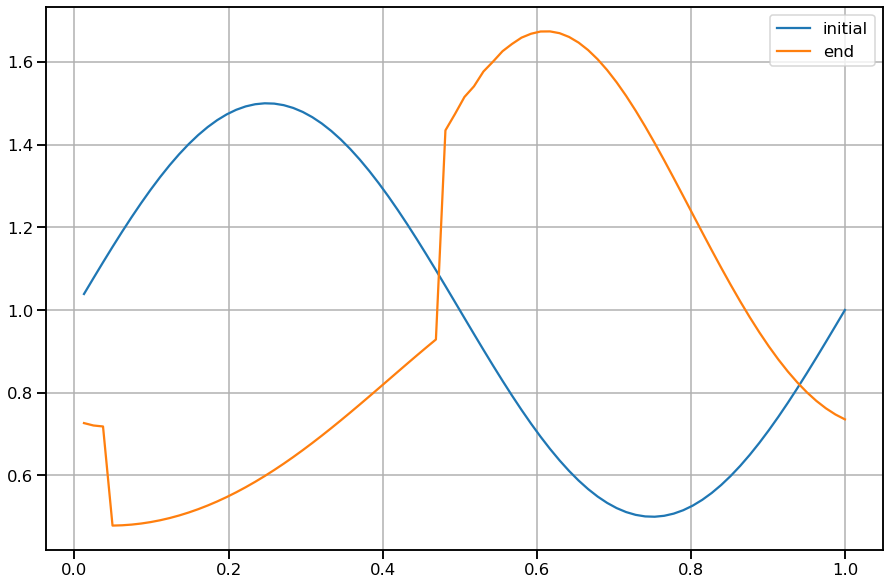

In [62]:
solver=DESolver()
solver.set_info(0)

mx=81

Flux_c=1.
Flux_cv=np.zeros((1,mx))
Flux_cv[:]=2.
Flux_cv[0,3:int(mx/2.)-2]=3.

pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection1D',pde_problem_setup)#('Navier-Stokes2D')
solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
#solver.set_method('RK4')
solver.set_method('MPRK2')
solver.set_rhs(rhs_e)
solver.set_rhs({'mr_explicit_fast':problem.rhs_e_fast,'mr_explicit_slow':problem.rhs_e_slow})

#if(rhs_i is not None):
#    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
#else:
#    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.005    
problem_setup['T_DURATION']['end']=1.
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u=solver.get_trajectory()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()


In [ ]:
problem_setup['context']['dx']

In [18]:
n=16
z=np.arange(n)
zF=z[0:int(n/2)]
zS=z[int(n/2):n]

print("zF : {:} {:}".format(zF.size,int(n/2)))
print("zS : {:} {:}".format(zS.size,n-int(n/2)))
print(z)
print(zF,zS)

zF : 8 8
zS : 8 8
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
[0 1 2 3 4 5 6 7] [ 8  9 10 11 12 13 14 15]


In [33]:
solver.view_registered_methods()

['RK4', 'RK3BS', 'RK2a', 'RK-FE', 'ETRS', 'ETRS-approx', 'ETRS-approx-FE', 'ARK2c', 'ARK2e', 'ARK3', 'ARK4', 'ARK5', 'ARKV10', 'BE', 'ESDIRK-CN', 'ESDIRK-ARK2e', 'GLEE-A9', 'GLEE-i2a', 'GLEE-1BEE', 'GLEE-2ARK2', 'RK2a-Trap', 'GLEE-A9-EIMEX', 'MPRK2']


['RK4',
 'RK3BS',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK2c',
 'ARK2e',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2']